### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

[7.40347657e-01 1.06014839e-01 6.14481888e-02 6.23223007e-01
 8.38058834e-01 1.15212470e-01 3.34454374e-01 1.83547676e+00
 2.69342031e+00 7.86232595e-02 1.59141741e+00 1.58096760e+00
 1.99633034e-03 4.94099963e-01 9.60588501e-02 1.00967413e+00
 7.36122413e-01 1.76426319e-01 4.76707028e-01 7.92421979e-01
 1.27978305e+00 1.71584964e-01 6.76799925e-01 4.40423140e-03
 1.21806053e-02 1.02419621e-01 1.66394889e+00 1.40531938e+00
 1.42683179e+00 1.82901061e+00 2.81625756e-01 5.47730382e-01
 7.98882088e-02 2.36476604e+00 5.57739824e-02 5.73036369e-01
 1.19557897e-01 2.78741843e-02 5.93877567e-01 1.60615225e+00
 2.09255108e-01 2.12582146e+00 1.13877985e-01 2.09893081e+00
 1.35847246e+00 1.46225362e+00 7.80806241e-02 3.13469603e-01
 7.88722225e-01 3.20051927e+00 5.88160905e-02 7.81711852e-01
 5.70466098e-01 1.63310154e-01 7.85522318e-01 3.18768643e-01
 1.00110751e+00 7.87706436e-02 2.08838671e+00 4.61900838e-01
 1.42582160e+00 2.98427126e+00 9.45767584e-01 2.13079411e+00
 1.51586435e-02 1.209497

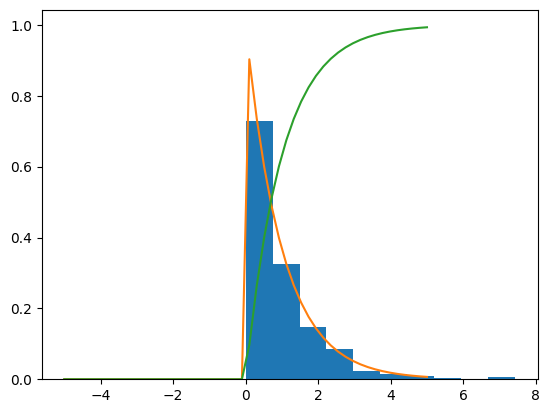

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

dist = sp.stats.gamma(1)
sample = dist.rvs(size=1000)
print(sample)
plt.hist(sample, density=True)
x = np.linspace(-5, 5)
plt.plot(x, dist.pdf(x), label='PDF')

cdf = dist.cdf(x)
plt.plot(x, cdf)

In [37]:
pip = sp.stats.gamma.fit(sample)
pip

(np.float64(0.9583527404224303),
 np.float64(0.00023030958760628142),
 np.float64(1.0917366783277869))

In [42]:
np.var(sample)

np.float64(1.0220538294175667)

### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

In [46]:
import math

def calculate_rmse(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    mse = sum((y_real[i] - y_pred[i]) ** 2 for i in range(len(y_real))) / len(y_real)
    return math.sqrt(mse)

def calculate_mae(y_real, y_pred):
    if len(y_real) != len(y_pred):
        raise ValueError("Le liste devono avere la stessa lunghezza.")
    errors = [abs(y_real[i] - y_pred[i]) for i in range(len(y_real))]
    return sum(errors) / len(errors)

[ 0  1  2  3  4  5  6  7  8  9 10 11]


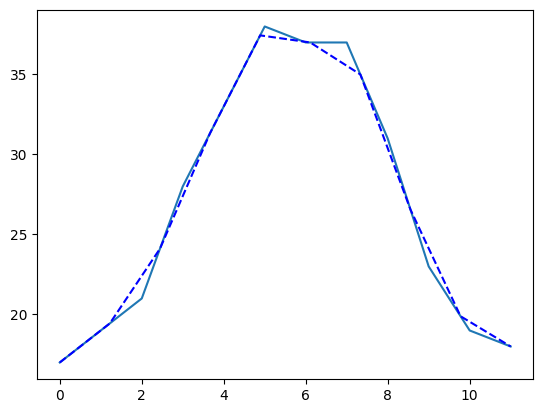

In [57]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

x_original = np.arange(len(temp_max))
print(x_original)
f_linear = interp1d(x_original, temp_max, kind='linear')
x_interp = np.linspace(0, len(temp_max)-1, 10)
y_interp = f_linear(x_interp)
plt.plot(temp_max)
plt.plot(x_interp, y_interp, label="Interpolazione SciPy (lineare)", linestyle='--', color='blue')


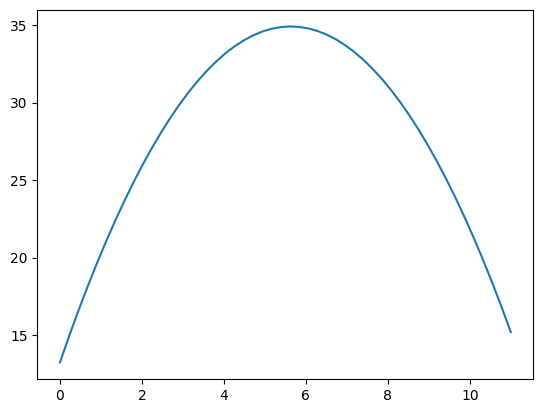

In [ ]:
def pol_x3(x, a, b, c, d):
    return a**3 + b*x**2 + c*x + d

params_max, _ = sp.optimize.curve_fit(pol_x3, x_original, temp_max)
x = np.linspace(0, 11)
plt.plot(x, pol_x3(x, *params_max))

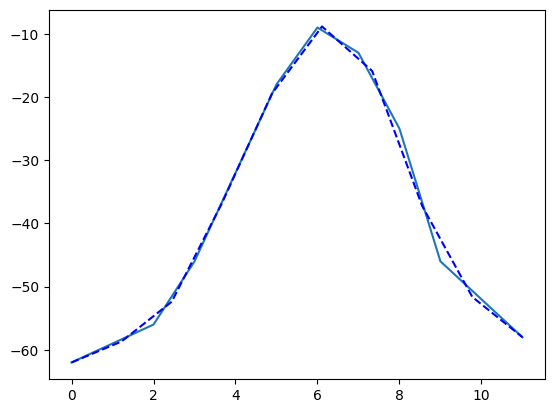

In [45]:
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
x_original = np.arange(len(temp_min))
f_linear = interp1d(x_original, temp_min, kind='cubic')
x_interp = np.linspace(0, len(temp_min)-1, 10)
y_interp = f_linear(x_interp)
plt.plot(temp_min)
plt.plot(x_interp, y_interp, label="Interpolazione SciPy (lineare)", linestyle='--', color='blue')


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [1]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


Coefficiente angolare (m): -0.04121511996278614
Intercetta (q): 29.59985475616395
R-quadro: 0.7183433404897298
P-value: 9.380326537381489e-10
Errore standard: 0.004711833309637005


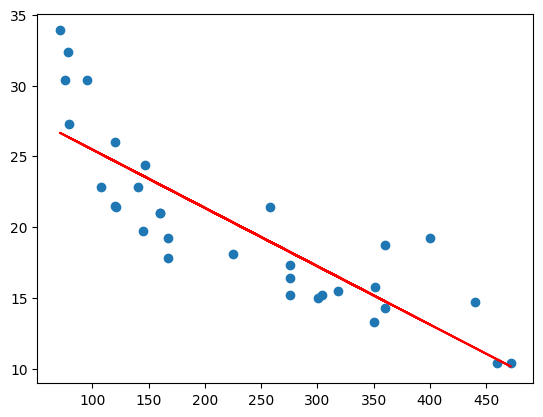

In [11]:
import matplotlib.pyplot as plt
import scipy as sp
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(df['disp'], df['mpg'])
y_fit_sp = slope * df['disp'] + intercept


# Output dei parametri
print(f"Coefficiente angolare (m): {slope}")
print(f"Intercetta (q): {intercept}")
print(f"R-quadro: {r_value**2}")
print(f"P-value: {p_value}")
print(f"Errore standard: {std_err}")

plt.scatter(df['disp'], df['mpg'])
plt.plot(df['disp'], y_fit_sp, label="Retta fittata", color="red")